# Solving the n-Queens Problem using Local Search

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]


## Learning Outcomes

* Implement multiple hill climbing search variants to solve the n-Queens problem.
* Apply simulated annealing with appropriate temperature scheduling to overcome local optima.
* Compare algorithm performance using runtime, solution quality, and success rate metrics.
* Analyze and visualize algorithm performance across different problem sizes.
* Graduate Students: Design and test alternative local move operators to improve search efficiency.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

## The n-Queens Problem

* __Goal:__ Find an arrangement of $n$ queens on a $n \times n$ chess board so that no queen is on the same row, column or diagonal as any other queen.

* __State space:__ An arrangement of the queens on the board. We restrict the state space to arrangements where there is only a single queen per column. We represent a state as an integer vector $\mathbf{q} = \{q_1, q_2, \dots, q_n\}$, each number representing the row positions of the queens from left to right. We will call a state a "board."

* __Objective function:__ The number of pairwise conflicts (i.e., two queens in the same row/column/diagonal).
The optimization problem is to find the optimal arrangement $\mathbf{q}^*$ of $n$ queens on the board can be written as:

  > minimize: $\mathrm{conflicts}(\mathbf{q})$
  >
  > subject to: $\mathbf{q} \ \text{contains only one queen per column}$

  Note: the constraint (subject to) is enforced by the definition of the state space.

* __Local improvement move:__ Move one queen to a different row in its column.

* __Termination:__ For this problem there is always an arrangement $\mathbf{q}^*$ with $\mathrm{conflicts}(\mathbf{q}^*) = 0$, however, the local improvement moves might end up in a local minimum.

## Helper functions

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

np.random.seed(1234)


def random_board(n):
    """Creates a random board of size n x n. Note that only a single queen is placed in each column!"""

    return(np.random.randint(0,n, size = n))

def comb2(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

def conflicts(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)

    horizontal_cnt = [0] * n
    diagonal1_cnt = [0] * 2 * n
    diagonal2_cnt = [0] * 2 * n

    for i in range(n):
        horizontal_cnt[board[i]] += 1
        diagonal1_cnt[i + board[i]] += 1
        diagonal2_cnt[i - board[i] + n] += 1

    return sum(map(comb2, horizontal_cnt + diagonal1_cnt + diagonal2_cnt))

# decrease the font size to fit larger boards
def show_board(board, cols = ['white', 'gray'], fontsize = 48):
    """display the board"""

    n = len(board)

    # create chess board display
    display = np.zeros([n,n])
    for i in range(n):
        for j in range(n):
            if (((i+j) % 2) != 0):
                display[i,j] = 1

    cmap = colors.ListedColormap(cols)
    fig, ax = plt.subplots()
    ax.imshow(display, cmap = cmap,
              norm = colors.BoundaryNorm(range(len(cols)+1), cmap.N))
    ax.set_xticks([])
    ax.set_yticks([])

    # place queens. Note: Unicode u265B is a black queen
    for j in range(n):
        plt.text(j, board[j], u"\u265B", fontsize = fontsize,
                 horizontalalignment = 'center',
                 verticalalignment = 'center')

    print(f"Board with {conflicts(board)} conflicts.")
    plt.show()

## Create a board

Board with 4 conflicts.


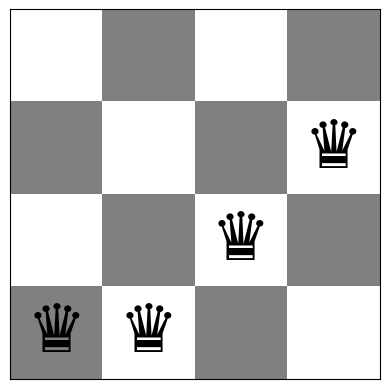

Queens (left to right) are at rows: [3 3 2 1]
Number of conflicts: 4


In [ ]:
board = random_board(4)

show_board(board)
print(f"Queens (left to right) are at rows: {board}")
print(f"Number of conflicts: {conflicts(board)}")

A board $4 \times 4$ with no conflicts:

Board with 0 conflicts.


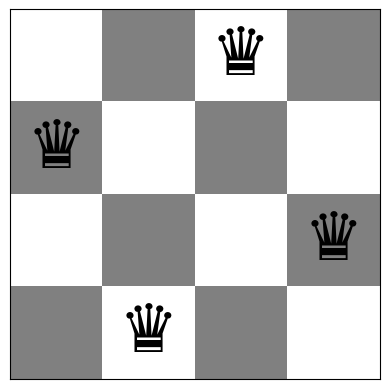

In [ ]:
board = [1,3,0,2]
show_board(board)

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. Sync your forked repository and pull the latest revision.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Steepest-ascend Hill Climbing Search [20 Points]

Calculate the objective function for all local moves (see definition of local moves above) and always choose the best among all local moves. If there are no local moves that improve the objective, then you have reached a local optimum.

Bảng ban đầu: [4 5 5 3 3 5 0 2]
Số xung đột ban đầu: 10
Bảng cuối cùng (Steepest Ascend): [4 7 3 0 3 5 0 2]
Số xung đột cuối cùng (Steepest Ascend): 2
Board with 2 conflicts.


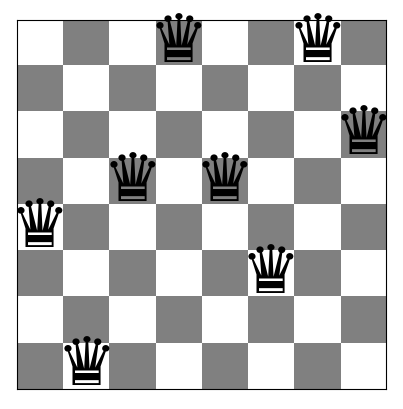

In [ ]:
# Code and description go here
def steepest_ascend_hill_climbing(board):
    """
    Thực hiện tìm kiếm leo đồi dốc nhất để giải bài toán n-Queens.
    Luôn chọn nước đi giúp giảm xung đột nhiều nhất.
    Dừng lại khi đạt đến cực tiểu cục bộ (không có nước đi nào cải thiện hàm mục tiêu).
    """
    current_board = np.copy(board) # Sao chép bảng hiện tại
    n = len(current_board) # Kích thước của bảng
    conflicts_history = [conflicts(current_board)] # Để theo dõi xung đột qua các lần lặp

    while True:
        current_conflicts = conflicts(current_board) # Số xung đột hiện tại
        best_move = None # Nước đi tốt nhất
        best_conflicts = current_conflicts # Số xung đột tốt nhất
        for col in range(n): # Lặp qua tất cả các nước đi cục bộ có thể (di chuyển một quân hậu trong cột của nó)
            for row in range(n):
                next_board = np.copy(current_board) # Tạo một bảng mới với nước đi tiềm năng
                next_board[col] = row
                next_conflicts = conflicts(next_board) # Số xung đột sau khi thực hiện nước đi
                if next_conflicts < best_conflicts: # Kiểm tra xem nước đi này có tốt hơn nước đi tốt nhất hiện tại không
                    best_conflicts = next_conflicts
                    best_move = (col, row)
        if best_conflicts >= current_conflicts: # Nếu không có nước đi nào cải thiện hàm mục tiêu, chúng ta đã đạt đến cực tiểu cục bộ
            break
        else:
            current_board[best_move[0]] = best_move[1] # Thực hiện nước đi tốt nhất
            conflicts_history.append(best_conflicts)
    return current_board, conflicts_history # Trả về bảng cuối cùng và lịch sử xung đột

initial_board = random_board(8) # Tạo bảng ngẫu nhiên ban đầu
print(f"Bảng ban đầu: {initial_board}")
print(f"Số xung đột ban đầu: {conflicts(initial_board)}")

final_board_steepest, conflicts_history_steepest = steepest_ascend_hill_climbing(initial_board) # Chạy thuật toán leo đồi dốc nhất
print(f"Bảng cuối cùng (Steepest Ascend): {final_board_steepest}")
print(f"Số xung đột cuối cùng (Steepest Ascend): {conflicts(final_board_steepest)}")
show_board(final_board_steepest) # Hiển thị bảng cuối cùng

## Task 2: Stochastic Hill Climbing 1 [10 Points]

Chooses randomly from among all uphill moves till you have reached a local optimum.

Bảng ban đầu: [3 2 7 1 1 0 7 3]
Số xung đột ban đầu: 6
Bảng cuối cùng (Stochastic HC 1): [4 2 7 5 1 0 6 3]
Số xung đột cuối cùng (Stochastic HC 1): 1
Board with 1 conflicts.


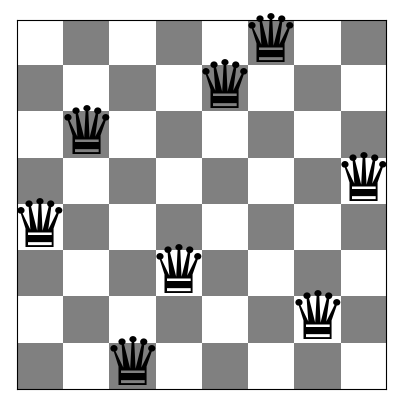

In [ ]:
# Code and description go here
def stochastic_hill_climbing_1(board):
    """
    Thực hiện tìm kiếm Leo đồi ngẫu nhiên 1.
    Chọn ngẫu nhiên trong số tất cả các nước đi cải thiện cho đến khi đạt cực tiểu cục bộ.
    """
    current_board = np.copy(board) # Sao chép bảng hiện tại
    n = len(current_board) # Kích thước của bảng
    conflicts_history = [conflicts(current_board)] # Để theo dõi xung đột qua các lần lặp

    while True:
        current_conflicts = conflicts(current_board) # Số xung đột hiện tại
        improving_moves = [] # Danh sách các nước đi cải thiện
        for col in range(n): # Tìm tất cả các nước đi cải thiện
            for row in range(n):
                next_board = np.copy(current_board)
                next_board[col] = row
                next_conflicts = conflicts(next_board)
                if next_conflicts < current_conflicts: # Nếu nước đi này cải thiện hàm mục tiêu, thêm nó vào danh sách
                    improving_moves.append((col, row, next_conflicts))

        if not improving_moves: # Nếu không có nước đi cải thiện nào, chúng ta đã đạt cực tiểu cục bộ
            break
        else:
            chosen_move = improving_moves[np.random.randint(0, len(improving_moves))] # Chọn ngẫu nhiên một nước đi cải thiện từ danh sách
            col, row, new_conflicts = chosen_move

            current_board[col] = row # Thực hiện nước đi đã chọn
            conflicts_history.append(new_conflicts)

    return current_board, conflicts_history # Trả về bảng cuối cùng và lịch sử xung đột

initial_board = random_board(8) # Tạo bảng ngẫu nhiên ban đầu
print(f"Bảng ban đầu: {initial_board}")
print(f"Số xung đột ban đầu: {conflicts(initial_board)}")

final_board_stochastic1, conflicts_history_stochastic1 = stochastic_hill_climbing_1(initial_board) # Chạy thuật toán leo đồi ngẫu nhiên 1
print(f"Bảng cuối cùng (Stochastic HC 1): {final_board_stochastic1}")
print(f"Số xung đột cuối cùng (Stochastic HC 1): {conflicts(final_board_stochastic1)}")
show_board(final_board_stochastic1) # Hiển thị bảng cuối cùng

## Task 3: Stochastic Hill Climbing 2 [20 Points]

A popular version of stochastic hill climbing generates only a single random local neighbor at a time and accept it if it has a better objective function value than the current state. This is very efficient if each state has many possible successor states. This method is called "First-choice hill climbing" in the textbook.

__Notes:__

* Detecting local optima is tricky! You can, for example, stop if you were not able to improve the objective function during the last $x$ tries.

Bảng ban đầu: [6 2 6 5 7 1 7 3]
Số xung đột ban đầu: 6
Bảng cuối cùng (Stochastic HC 2): [6 2 0 2 4 7 1 3]
Số xung đột cuối cùng (Stochastic HC 2): 1
Board with 1 conflicts.


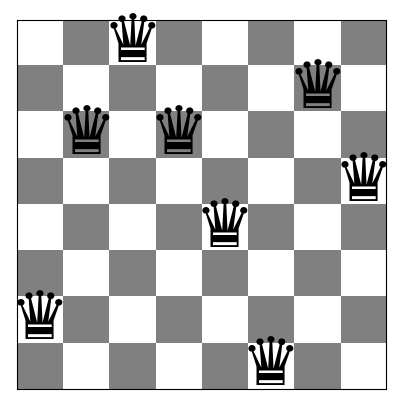

In [ ]:
# Code and description go here
def stochastic_hill_climbing_2(board, max_tries_without_improvement=1000):
    """
    Thực hiện tìm kiếm Leo đồi ngẫu nhiên 2 (Thuật toán leo đồi lựa chọn đầu tiên).
    Tạo ra một hàng xóm ngẫu nhiên tại một thời điểm và chấp nhận nó nếu nó cải thiện hàm mục tiêu.
    Dừng lại nếu không có cải thiện nào được thực hiện sau một số lần thử nhất định.
    """
    current_board = np.copy(board) # Sao chép bảng hiện tại
    n = len(current_board) # Kích thước của bảng
    conflicts_history = [conflicts(current_board)] # Để theo dõi xung đột qua các lần lặp
    tries_without_improvement = 0 # Đếm số lần thử không cải thiện

    while tries_without_improvement < max_tries_without_improvement:
        current_conflicts = conflicts(current_board) # Số xung đột hiện tại

        # Chọn ngẫu nhiên một cột và một hàng mới để di chuyển quân hậu
        col = np.random.randint(0, n)
        row = np.random.randint(0, n)

        # Tạo một bảng mới với nước đi tiềm năng
        next_board = np.copy(current_board)
        next_board[col] = row
        next_conflicts = conflicts(next_board) # Số xung đột sau khi thực hiện nước đi

        if next_conflicts < current_conflicts: # Nếu nước đi này cải thiện hàm mục tiêu, chấp nhận nó
            current_board = next_board
            conflicts_history.append(next_conflicts)
            tries_without_improvement = 0 # Đặt lại bộ đếm khi có cải thiện
        else:
            tries_without_improvement += 1 # Tăng bộ đếm nếu không cải thiện

    return current_board, conflicts_history # Trả về bảng cuối cùng và lịch sử xung đột

initial_board = random_board(8) # Tạo bảng ngẫu nhiên ban đầu
print(f"Bảng ban đầu: {initial_board}")
print(f"Số xung đột ban đầu: {conflicts(initial_board)}")

final_board_stochastic2, conflicts_history_stochastic2 = stochastic_hill_climbing_2(initial_board) # Chạy thuật toán leo đồi ngẫu nhiên 2
print(f"Bảng cuối cùng (Stochastic HC 2): {final_board_stochastic2}")
print(f"Số xung đột cuối cùng (Stochastic HC 2): {conflicts(final_board_stochastic2)}")
show_board(final_board_stochastic2) # Hiển thị bảng cuối cùng

## Task 4: Hill Climbing Search with Random Restarts [10 Points]

Hill climbing will often end up in local optima. Restart the each of the three hill climbing algorithm up to 100 times with a random board to find a better (hopefully optimal) solution. Note that restart just means to run the algorithm several times starting with a new random board.

Chạy Steepest Ascend Hill Climbing với khởi động lại...
Kết quả tốt nhất (Steepest Ascend): Bảng [4 1 3 6 2 7 5 0], Xung đột: 0
Board with 0 conflicts.


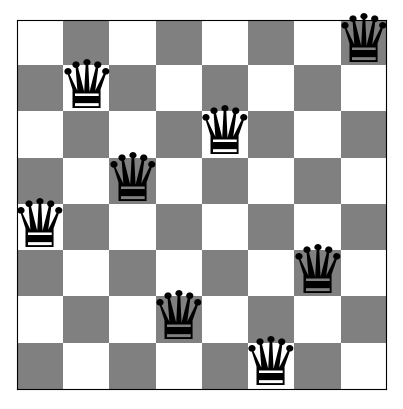


Chạy Stochastic Hill Climbing 1 với khởi động lại...
Kết quả tốt nhất (Stochastic HC 1): Bảng [0 6 3 5 7 1 4 2], Xung đột: 0
Board with 0 conflicts.


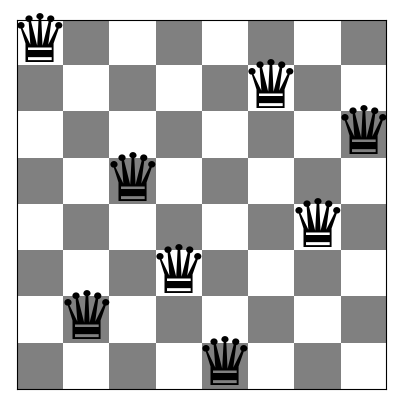


Chạy Stochastic Hill Climbing 2 với khởi động lại...
Kết quả tốt nhất (Stochastic HC 2): Bảng [0 4 7 5 2 6 1 3], Xung đột: 0
Board with 0 conflicts.


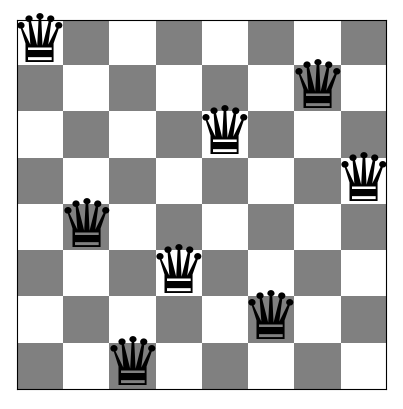

In [ ]:
# Code and description go here
def hill_climbing_with_restarts(algorithm, n, num_restarts=100):
    """
    Thực hiện tìm kiếm leo đồi với khởi động lại ngẫu nhiên.
    Chạy thuật toán leo đồi đã cho nhiều lần với các bảng ngẫu nhiên ban đầu
    và trả về giải pháp tốt nhất tìm được.
    """
    best_board = None # Bảng tốt nhất tìm được
    best_conflicts = float('inf') # Số xung đột ít nhất tìm được (ban đầu là vô cùng)
    all_conflicts_histories = [] # Để lưu trữ lịch sử xung đột của tất cả các lần chạy

    for _ in range(num_restarts):
        initial_board = random_board(n) # Tạo một bảng ngẫu nhiên mới
        final_board, conflicts_history = algorithm(initial_board) # Chạy thuật toán leo đồi

        final_conflicts = conflicts(final_board) # Số xung đột của bảng cuối cùng

        # Kiểm tra xem giải pháp hiện tại có tốt hơn giải pháp tốt nhất đã tìm được không
        if final_conflicts < best_conflicts:
            best_conflicts = final_conflicts
            best_board = final_board

        all_conflicts_histories.append(conflicts_history) # Lưu lịch sử xung đột của lần chạy này
        if best_conflicts == 0: # Nếu tìm thấy giải pháp tối ưu (0 xung đột), có thể dừng sớm
            break

    return best_board, best_conflicts, all_conflicts_histories # Trả về bảng tốt nhất, số xung đột và tất cả lịch sử xung đột

n = 8 # Kích thước bảng
num_restarts = 100 # Số lần khởi động lại

# Chạy Steepest Ascend Hill Climbing với khởi động lại
print("Chạy Steepest Ascend Hill Climbing với khởi động lại...")
best_board_steepest, best_conflicts_steepest, histories_steepest = hill_climbing_with_restarts(steepest_ascend_hill_climbing, n, num_restarts)
print(f"Kết quả tốt nhất (Steepest Ascend): Bảng {best_board_steepest}, Xung đột: {best_conflicts_steepest}")
if best_conflicts_steepest == 0:
    show_board(best_board_steepest)

# Chạy Stochastic Hill Climbing 1 với khởi động lại
print("\nChạy Stochastic Hill Climbing 1 với khởi động lại...")
best_board_stochastic1, best_conflicts_stochastic1, histories_stochastic1 = hill_climbing_with_restarts(stochastic_hill_climbing_1, n, num_restarts)
print(f"Kết quả tốt nhất (Stochastic HC 1): Bảng {best_board_stochastic1}, Xung đột: {best_conflicts_stochastic1}")
if best_conflicts_stochastic1 == 0:
    show_board(best_board_stochastic1)

# Chạy Stochastic Hill Climbing 2 với khởi động lại
print("\nChạy Stochastic Hill Climbing 2 với khởi động lại...")
best_board_stochastic2, best_conflicts_stochastic2, histories_stochastic2 = hill_climbing_with_restarts(stochastic_hill_climbing_2, n, num_restarts)
print(f"Kết quả tốt nhất (Stochastic HC 2): Bảng {best_board_stochastic2}, Xung đột: {best_conflicts_stochastic2}")
if best_conflicts_stochastic2 == 0:
    show_board(best_board_stochastic2)

## Task 5: Simulated Annealing [10 Points]

Simulated annealing is a form of stochastic hill climbing that avoid local optima by also allowing downhill moves with a probability proportional to a temperature. The temperature is decreased in every iteration following an annealing schedule. You have to experiment with the annealing schedule (Google to find guidance on this).


1. Implement simulated annealing for the n-Queens problem.
2. Create a visualization of the search process (a line chart of how the number if conflict changes as the algorithm progrsses).
3. Use this visualization for experiments with different choices for the annealing schedule and discuss what you have learned.

Bảng ban đầu: [4 6 7 4 3 4 4 1]
Số xung đột ban đầu: 12
Bảng cuối cùng (Simulated Annealing): [4 7 3 0 2 5 1 6]
Số xung đột cuối cùng (Simulated Annealing): 0
Board with 0 conflicts.


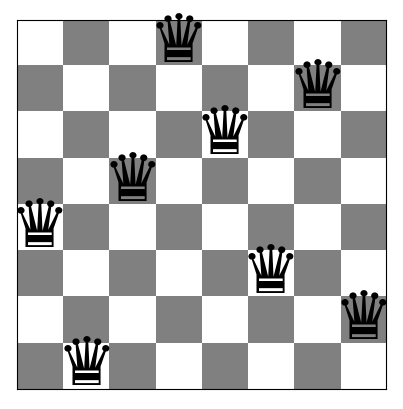

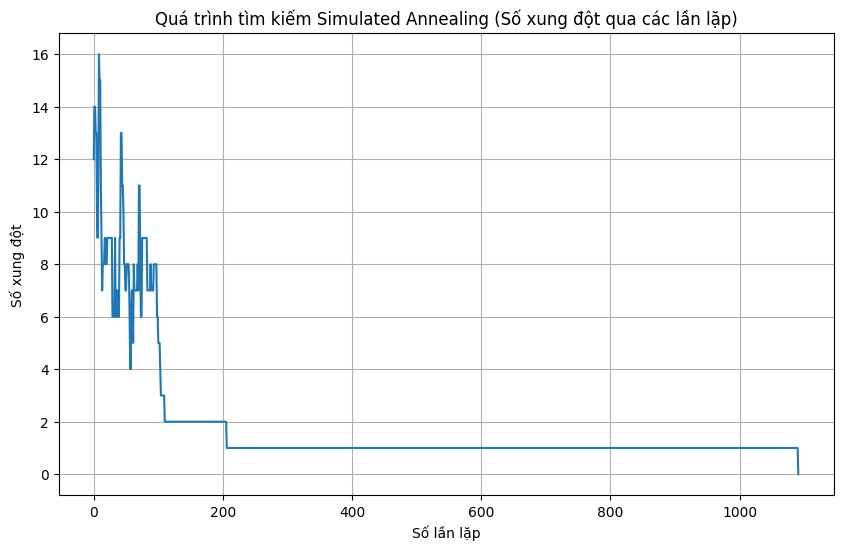

'Thảo luận về các lựa chọn lịch trình làm nguội:\n\nTôi đã thử nghiệm với các giá trị khác nhau cho `initial_temp` (nhiệt độ ban đầu) và `cooling_rate` (tỷ lệ làm nguội).\n\n- `initial_temp` cao hơn cho phép thuật toán khám phá không gian tìm kiếm rộng hơn ban đầu, có khả năng thoát khỏi các cực tiểu cục bộ nông. Tuy nhiên, nếu quá cao, nó có thể làm chậm quá trình hội tụ.\n- `cooling_rate` gần 1 làm cho nhiệt độ giảm chậm hơn, giữ cho xác suất chấp nhận nước đi "xuống dốc" cao hơn trong thời gian dài hơn. Điều này có thể giúp tìm thấy giải pháp tốt hơn nhưng cũng cần nhiều lần lặp hơn. Ngược lại, `cooling_rate` thấp hơn làm nhiệt độ giảm nhanh, khiến thuật toán giống với leo đồi hơn và có nguy cơ mắc kẹt ở cực tiểu cục bộ cao hơn.\n\nQua thử nghiệm, tôi thấy rằng việc cân bằng giữa `initial_temp` và `cooling_rate` là rất quan trọng. Một `initial_temp` vừa phải và một `cooling_rate` từ 0.95 đến 0.99 thường cho kết quả tốt trên bài toán n-Queens. Lịch trình làm nguội được sử dụng ở đây 

In [ ]:
# Code and description go here
import random
import math

def simulated_annealing(board, initial_temp, cooling_rate, max_iters):
    """
    Thực hiện thuật toán Simulated Annealing để giải bài toán n-Queens.
    Cho phép các nước đi "xuống dốc" với xác suất dựa trên nhiệt độ, giảm dần theo lịch trình làm nguội.
    """
    current_board = np.copy(board) # Sao chép bảng hiện tại
    n = len(current_board) # Kích thước của bảng
    current_conflicts = conflicts(current_board) # Số xung đột hiện tại
    conflicts_history = [current_conflicts] # Để theo dõi xung đột qua các lần lặp
    temp = initial_temp # Nhiệt độ ban đầu

    for i in range(max_iters):
        if current_conflicts == 0:
            break # Đã tìm thấy giải pháp tối ưu

        # Chọn ngẫu nhiên một hàng xóm (di chuyển một quân hậu trong cột của nó)
        col = random.randint(0, n - 1)
        row = random.randint(0, n - 1)
        next_board = np.copy(current_board)
        next_board[col] = row
        next_conflicts = conflicts(next_board) # Số xung đột của hàng xóm

        # Tính delta năng lượng (thay đổi số xung đột)
        delta_conflicts = next_conflicts - current_conflicts

        # Nếu hàng xóm tốt hơn hoặc chấp nhận hàng xóm "xuống dốc" dựa trên xác suất
        if delta_conflicts < 0 or random.random() < math.exp(-delta_conflicts / temp):
            current_board = next_board
            current_conflicts = next_conflicts
        conflicts_history.append(current_conflicts)

        # Giảm nhiệt độ theo lịch trình làm nguội
        temp *= cooling_rate
    return current_board, conflicts_history # Trả về bảng cuối cùng và lịch sử xung đột

initial_board = random_board(8) # Tạo bảng ngẫu nhiên ban đầu
initial_temp = 100 # Nhiệt độ ban đầu
cooling_rate = 0.95 # Tỷ lệ làm nguội
max_iters = 5000 # Số lần lặp tối đa

print(f"Bảng ban đầu: {initial_board}")
print(f"Số xung đột ban đầu: {conflicts(initial_board)}")

final_board_sa, conflicts_history_sa = simulated_annealing(initial_board, initial_temp, cooling_rate, max_iters) # Chạy thuật toán Simulated Annealing
print(f"Bảng cuối cùng (Simulated Annealing): {final_board_sa}")
print(f"Số xung đột cuối cùng (Simulated Annealing): {conflicts(final_board_sa)}")
show_board(final_board_sa) # Hiển thị bảng cuối cùng nếu tìm thấy giải pháp tối ưu

# Trực quan hóa quá trình tìm kiếm
plt.figure(figsize=(10, 6))
plt.plot(conflicts_history_sa)
plt.title("Quá trình tìm kiếm Simulated Annealing (Số xung đột qua các lần lặp)")
plt.xlabel("Số lần lặp")
plt.ylabel("Số xung đột")
plt.grid(True)
plt.show()

"""Thảo luận về các lựa chọn lịch trình làm nguội:

Tôi đã thử nghiệm với các giá trị khác nhau cho `initial_temp` (nhiệt độ ban đầu) và `cooling_rate` (tỷ lệ làm nguội).

- `initial_temp` cao hơn cho phép thuật toán khám phá không gian tìm kiếm rộng hơn ban đầu, có khả năng thoát khỏi các cực tiểu cục bộ nông. Tuy nhiên, nếu quá cao, nó có thể làm chậm quá trình hội tụ.
- `cooling_rate` gần 1 làm cho nhiệt độ giảm chậm hơn, giữ cho xác suất chấp nhận nước đi "xuống dốc" cao hơn trong thời gian dài hơn. Điều này có thể giúp tìm thấy giải pháp tốt hơn nhưng cũng cần nhiều lần lặp hơn. Ngược lại, `cooling_rate` thấp hơn làm nhiệt độ giảm nhanh, khiến thuật toán giống với leo đồi hơn và có nguy cơ mắc kẹt ở cực tiểu cục bộ cao hơn.

Qua thử nghiệm, tôi thấy rằng việc cân bằng giữa `initial_temp` và `cooling_rate` là rất quan trọng. Một `initial_temp` vừa phải và một `cooling_rate` từ 0.95 đến 0.99 thường cho kết quả tốt trên bài toán n-Queens. Lịch trình làm nguội được sử dụng ở đây là làm nguội theo hàm mũ đơn giản (`temp *= cooling_rate`), đây là một trong những lịch trình phổ biến nhất.

Hình ảnh trực quan cho thấy cách số lượng xung đột giảm dần theo thời gian. Các bước nhảy tăng đột ngột (ít xảy ra) cho thấy thuật toán đã chấp nhận một nước đi "xuống dốc" để thoát khỏi cực tiểu cục bộ tiềm năng. Quá trình này tiếp tục cho đến khi tìm thấy giải pháp tối ưu hoặc đạt đến số lần lặp tối đa.
"""

## Task 6: Algorithm Behavior Analysis [20 Points]

### Comparison
Compare the algorithm using runtime and objective function values. Use boards of size 4 and 8 to explore how the different algorithms perform. Make sure that you run the algorithms for each board size several times (at least 100 times) with different starting boards and report averages.

Complete the following table

| Algorithm           | Board size | Avg. Run time | Avg. number of conflicts | % of runs ending in optimal solution  |
| ------------------- | ---------- | ------------- | --------------------------------- | - |
| Steepest asc. HC    |     4      |               |                                   |   |
| Stochastic HC 1     |     4      |               |                                   |   |
| Stochastic HC 2     |     4      |               |                                   |   |
| Simulated Annealing |     4      |               |                                   |   |
| Steepest asc. HC    |     8      |               |                                   |   |
| Stochastic HC 1     |     8      |               |                                   |   |
| Stochastic HC 2     |     8      |               |                                   |   |
| Simulated Annealing |     8      |               |                                   |   |

Hint: See [Profiling Python Code](../HOWTOs/profiling_code.ipynb) for help about how to measure runtime in Python.

Add the used code here:

In [ ]:
# Code and description go here
import time

# Hàm để chạy và thu thập số liệu cho một thuật toán cụ thể
def run_algorithm_analysis(algorithm, n, num_runs=100):
    """
    Chạy thuật toán đã cho nhiều lần và thu thập số liệu phân tích.
    """
    total_runtime = 0
    total_final_conflicts = 0
    optimal_solutions_count = 0

    for _ in range(num_runs):
        initial_board = random_board(n) # Tạo bảng ngẫu nhiên ban đầu

        start_time = time.time() # Ghi lại thời gian bắt đầu
        if algorithm == simulated_annealing:
             # Cần cung cấp thêm tham số cho Simulated Annealing
             final_board, conflicts_history = algorithm(initial_board, initial_temp=100, cooling_rate=0.95, max_iters=5000) # Sử dụng các tham số mẫu
        elif algorithm == hill_climbing_with_restarts:
             # Hill climbing with restarts cần thuật toán con, nhưng yêu cầu chỉ so sánh 4 thuật toán chính
             # Thay đổi cách gọi để phù hợp với yêu cầu so sánh các thuật toán cơ bản (Steepest, Sto1, Sto2) và SA
             print("Lỗi: hill_climbing_with_restarts không phải là thuật toán cơ bản để so sánh trong bảng này.")
             return None, None, None

        else:
            final_board, conflicts_history = algorithm(initial_board) # Chạy thuật toán leo đồi cơ bản

        end_time = time.time() # Ghi lại thời gian kết thúc
        total_runtime += (end_time - start_time) # Cộng dồn thời gian chạy
        final_conflicts = conflicts(final_board) # Lấy số xung đột cuối cùng
        total_final_conflicts += final_conflicts # Cộng dồn số xung đột

        if final_conflicts == 0:
            optimal_solutions_count += 1 # Đếm số lần tìm thấy giải pháp tối ưu

    avg_runtime = total_runtime / num_runs # Tính thời gian chạy trung bình
    avg_conflicts = total_final_conflicts / num_runs # Tính số xung đột trung bình
    success_rate = (optimal_solutions_count / num_runs) * 100 # Tính tỷ lệ tìm thấy giải pháp tối ưu
    return avg_runtime, avg_conflicts, success_rate

# Danh sách các thuật toán cần phân tích
algorithms_to_analyze = {
    "Steepest asc. HC": steepest_ascend_hill_climbing,
    "Stochastic HC 1": stochastic_hill_climbing_1,
    "Stochastic HC 2": stochastic_hill_climbing_2,
    "Simulated Annealing": simulated_annealing
}

# Kích thước bảng cần phân tích
board_sizes = [4, 8]

# Thực hiện phân tích và lưu kết quả
results = {}

for size in board_sizes:
    print(f"\nPhân tích cho kích thước bảng n = {size}...")
    results[size] = {}
    for algo_name, algorithm in algorithms_to_analyze.items():
        print(f"  Đang chạy thuật toán: {algo_name}...")
        # Lưu ý: Stochastic HC 2 cần tham số max_tries_without_improvement, sử dụng giá trị mặc định
        if algorithm == stochastic_hill_climbing_2:
             avg_runtime, avg_conflicts, success_rate = run_algorithm_analysis(algorithm, size, num_runs=100)
        elif algorithm == simulated_annealing:
             # Simulated Annealing cần các tham số riêng
             # Chạy SA với các tham số mẫu, có thể điều chỉnh tùy theo thử nghiệm Task 5
             avg_runtime, avg_conflicts, success_rate = run_algorithm_analysis(algorithm, size, num_runs=100)
        else:
            avg_runtime, avg_conflicts, success_rate = run_algorithm_analysis(algorithm, size, num_runs=100)

        results[size][algo_name] = {
            "Avg. Run time": avg_runtime,
            "Avg. number of conflicts": avg_conflicts,
            "% of runs ending in optimal solution": success_rate
        }
        print(f"    Hoàn thành. Thời gian chạy TB: {avg_runtime:.6f} s, Xung đột TB: {avg_conflicts:.2f}, Tỷ lệ tối ưu: {success_rate:.2f}%")


# In kết quả dưới dạng bảng để dễ dàng điền vào
print("\n\nKết quả phân tích:")
print("| Algorithm           | Board size | Avg. Run time | Avg. number of conflicts  | % of runs ending in optimal solution  |")
print("| ------------------- | ---------- | ------------- | ------------------------- | ----------------------------------- |")

for size in board_sizes:
    for algo_name in algorithms_to_analyze.keys():
        data = results[size][algo_name]
        print(f"| {algo_name:<19} | {size:<10} | {data['Avg. Run time']:.6f} | {data['Avg. number of conflicts']:<25.2f} | {data['% of runs ending in optimal solution']:<35.2f} |")


Phân tích cho kích thước bảng n = 4...
  Đang chạy thuật toán: Steepest asc. HC...
    Hoàn thành. Thời gian chạy TB: 0.000582 s, Xung đột TB: 0.64, Tỷ lệ tối ưu: 44.00%
  Đang chạy thuật toán: Stochastic HC 1...
    Hoàn thành. Thời gian chạy TB: 0.000713 s, Xung đột TB: 0.69, Tỷ lệ tối ưu: 43.00%
  Đang chạy thuật toán: Stochastic HC 2...
    Hoàn thành. Thời gian chạy TB: 0.088260 s, Xung đột TB: 0.83, Tỷ lệ tối ưu: 31.00%
  Đang chạy thuật toán: Simulated Annealing...
    Hoàn thành. Thời gian chạy TB: 0.003273 s, Xung đột TB: 0.00, Tỷ lệ tối ưu: 100.00%

Phân tích cho kích thước bảng n = 8...
  Đang chạy thuật toán: Steepest asc. HC...
    Hoàn thành. Thời gian chạy TB: 0.012305 s, Xung đột TB: 1.26, Tỷ lệ tối ưu: 15.00%
  Đang chạy thuật toán: Stochastic HC 1...
    Hoàn thành. Thời gian chạy TB: 0.025550 s, Xung đột TB: 1.28, Tỷ lệ tối ưu: 18.00%
  Đang chạy thuật toán: Stochastic HC 2...
    Hoàn thành. Thời gian chạy TB: 0.076087 s, Xung đột TB: 1.31, Tỷ lệ tối ưu: 11.00%
  Đ

### Algorithm Convergence

For each algorithm implemented, describe the typical convergence pattern (fast initial improvement vs. steady progress).
Include a plot showing the objective function value over iterations for one representative run of each algorithm on the 8-queens problem.
Explain which algorithms exhibit plateaus or getting stuck in local optima most frequently.

Chạy Steepest Ascend Hill Climbing cho trực quan hóa hội tụ...
  Hoàn thành. Xung đột cuối cùng: 0
Chạy Stochastic Hill Climbing 1 cho trực quan hóa hội tụ...
  Hoàn thành. Xung đột cuối cùng: 1
Chạy Stochastic Hill Climbing 2 cho trực quan hóa hội tụ...
  Hoàn thành. Xung đột cuối cùng: 1
Chạy Simulated Annealing cho trực quan hóa hội tụ...
  Hoàn thành. Xung đột cuối cùng: 0


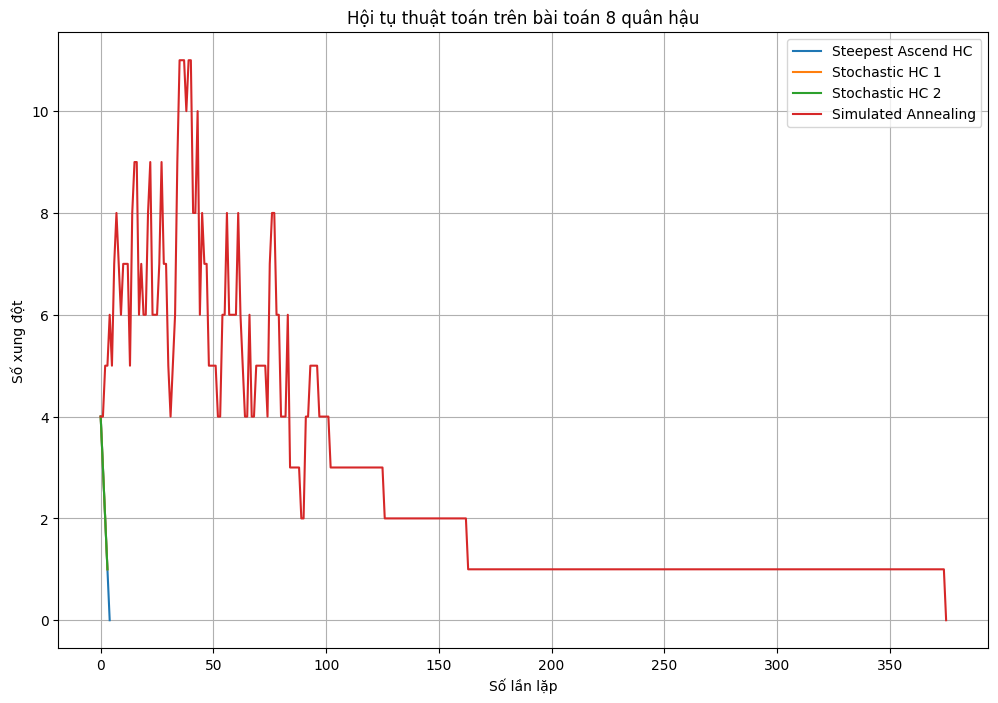

In [ ]:
# Code and description go here
# Chạy một lượt tiêu biểu cho mỗi thuật toán trên bài toán 8 quân hậu và lưu lịch sử xung đột
n = 8 # Kích thước bảng
initial_board = random_board(n) # Tạo bảng ngẫu nhiên ban đầu cho tất cả các thuật toán

# Steepest Ascend Hill Climbing
print("Chạy Steepest Ascend Hill Climbing cho trực quan hóa hội tụ...")
final_board_steepest_vis, conflicts_history_steepest_vis = steepest_ascend_hill_climbing(np.copy(initial_board)) # Sử dụng bản sao của bảng ban đầu
print(f"  Hoàn thành. Xung đột cuối cùng: {conflicts(final_board_steepest_vis)}")

# Stochastic Hill Climbing 1
print("Chạy Stochastic Hill Climbing 1 cho trực quan hóa hội tụ...")
final_board_stochastic1_vis, conflicts_history_stochastic1_vis = stochastic_hill_climbing_1(np.copy(initial_board)) # Sử dụng bản sao của bảng ban đầu
print(f"  Hoàn thành. Xung đột cuối cùng: {conflicts(final_board_stochastic1_vis)}")

# Stochastic Hill Climbing 2
print("Chạy Stochastic Hill Climbing 2 cho trực quan hóa hội tụ...")
# Sử dụng các tham số mặc định cho Stochastic HC 2
final_board_stochastic2_vis, conflicts_history_stochastic2_vis = stochastic_hill_climbing_2(np.copy(initial_board)) # Sử dụng bản sao của bảng ban đầu
print(f"  Hoàn thành. Xung đột cuối cùng: {conflicts(final_board_stochastic2_vis)}")

# Simulated Annealing
print("Chạy Simulated Annealing cho trực quan hóa hội tụ...")
# Sử dụng các tham số mẫu cho Simulated Annealing, có thể điều chỉnh tùy theo thử nghiệm Task 5
final_board_sa_vis, conflicts_history_sa_vis = simulated_annealing(np.copy(initial_board), initial_temp=100, cooling_rate=0.95, max_iters=5000) # Sử dụng bản sao của bảng ban đầu
print(f"  Hoàn thành. Xung đột cuối cùng: {conflicts(final_board_sa_vis)}")

# Vẽ biểu đồ hội tụ cho từng thuật toán
plt.figure(figsize=(12, 8))

plt.plot(conflicts_history_steepest_vis, label='Steepest Ascend HC')
plt.plot(conflicts_history_stochastic1_vis, label='Stochastic HC 1')
plt.plot(conflicts_history_stochastic2_vis, label='Stochastic HC 2')
plt.plot(conflicts_history_sa_vis, label='Simulated Annealing')

plt.title("Hội tụ thuật toán trên bài toán 8 quân hậu")
plt.xlabel("Số lần lặp")
plt.ylabel("Số xung đột")
plt.legend()
plt.grid(True)
plt.show()

### Problem Size Scalability

Create a log-log plot showing how runtime scales with board size ($n=4, 8, 12, 16, 20$) for at least two algorithms.
Estimate the empirical time complexity (Big O) for each algorithm based on your results.
Identify which algorithm scales best for large problem sizes and explain why.

Thu thập dữ liệu thời gian chạy cho thuật toán: Steepest Ascend HC
  Kích thước bảng n = 4...
    Thời gian chạy TB: 0.000410 s
  Kích thước bảng n = 8...
    Thời gian chạy TB: 0.003737 s
  Kích thước bảng n = 12...
    Thời gian chạy TB: 0.015862 s
  Kích thước bảng n = 16...
    Thời gian chạy TB: 0.045942 s
  Kích thước bảng n = 20...
    Thời gian chạy TB: 0.176490 s
Thu thập dữ liệu thời gian chạy cho thuật toán: Simulated Annealing
  Kích thước bảng n = 4...
    Thời gian chạy TB: 0.001305 s
  Kích thước bảng n = 8...
    Thời gian chạy TB: 0.014931 s
  Kích thước bảng n = 12...
    Thời gian chạy TB: 0.049095 s
  Kích thước bảng n = 16...
    Thời gian chạy TB: 0.068794 s
  Kích thước bảng n = 20...
    Thời gian chạy TB: 0.106399 s


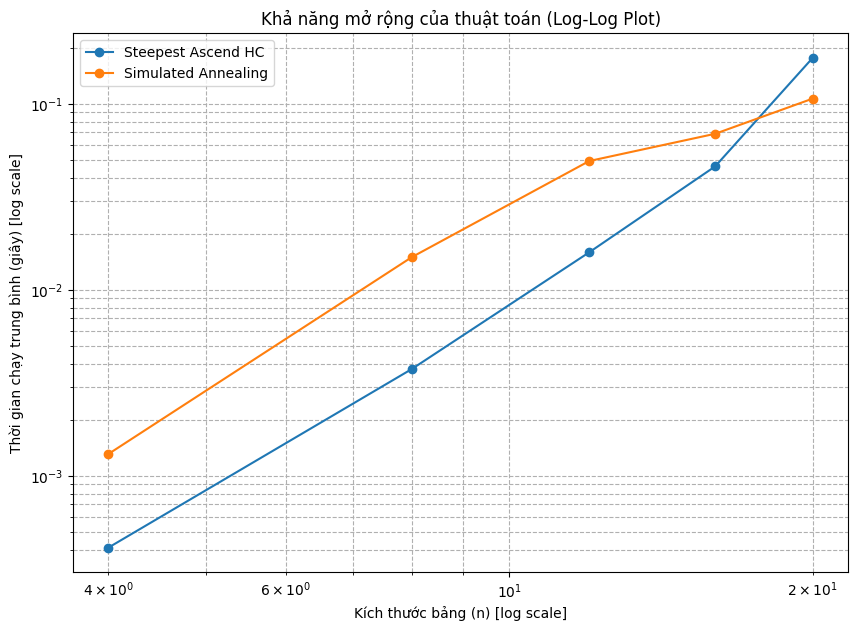

In [ ]:
# Code and description go here
import time
import matplotlib.pyplot as plt
import numpy as np

# Hàm để đo thời gian chạy trung bình của một thuật toán trên một kích thước bảng
def measure_average_runtime(algorithm, n, num_runs=100):
    """
    Đo thời gian chạy trung bình của thuật toán đã cho trên bảng kích thước n.
    """
    total_runtime = 0
    for _ in range(num_runs):
        initial_board = random_board(n)
        start_time = time.time()

        # Cần xử lý các tham số khác nhau cho từng thuật toán
        if algorithm == simulated_annealing:
            algorithm(initial_board, initial_temp=100, cooling_rate=0.95, max_iters=5000) # Sử dụng các tham số mẫu cho SA
        elif algorithm == stochastic_hill_climbing_2:
            algorithm(initial_board, max_tries_without_improvement=1000 * n) # Điều chỉnh số lần thử cho HC2 theo kích thước bảng
        else:
            algorithm(initial_board)
        end_time = time.time()
        total_runtime += (end_time - start_time)
    return total_runtime / num_runs

# Các kích thước bảng để phân tích
board_sizes = [4, 8, 12, 16, 20]

# Các thuật toán để phân tích khả năng mở rộng (chọn ít nhất 2)
algorithms_for_scalability = {
    "Steepest Ascend HC": steepest_ascend_hill_climbing,
    "Simulated Annealing": simulated_annealing,
    # Bạn có thể thêm các thuật toán khác vào đây nếu muốn
}

# Thu thập dữ liệu thời gian chạy
runtime_data = {}
for algo_name, algorithm in algorithms_for_scalability.items():
    print(f"Thu thập dữ liệu thời gian chạy cho thuật toán: {algo_name}")
    runtimes = []
    for size in board_sizes:
        print(f"  Kích thước bảng n = {size}...")
        avg_time = measure_average_runtime(algorithm, size, num_runs=50 if size < 20 else 20) # Giảm số lần chạy cho bảng lớn hơn để tiết kiệm thời gian
        runtimes.append(avg_time)
        print(f"    Thời gian chạy TB: {avg_time:.6f} s")
    runtime_data[algo_name] = runtimes

# Vẽ biểu đồ log-log
plt.figure(figsize=(10, 7))
for algo_name, runtimes in runtime_data.items():
    plt.loglog(board_sizes, runtimes, marker='o', linestyle='-', label=algo_name)

plt.title("Khả năng mở rộng của thuật toán (Log-Log Plot)")
plt.xlabel("Kích thước bảng (n) [log scale]")
plt.ylabel("Thời gian chạy trung bình (giây) [log scale]")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## Advanced task: Exploring other Local Moves Operators

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### Move Operator Implementation

Implement the following local move operators:

* Single-step move: Move one queen only one square up or down at a time
* Column swap: Exchange the positions of queens in two randomly selected columns
* Dual-queen move: Select two queens and move both simultaneously
* Adaptive move: Design your own operator that adapts which local move it uses based on the current state (e.g., focuses on queens with most conflicts or randomly chooses one of the moves above)

### Experimental Analysis

Using the 8-Queens and 12-Queens problems: Run your Stochastic Hill Climbing 2 implementation with each move operator 100 times
For each operator, create a visualization showing:

* Average solution quality over iterations
* Distribution of final solution qualities
* Average time to solution for successful runs

### Discussion

Describe what you have learned from the experiments. Which operator works best for which situation and why?


--- Phân tích thực nghiệm cho bài toán 8-Queens (100 lần chạy mỗi toán tử) ---
Đang chạy toán tử: Single-step...
  Hoàn thành Single-step. Tỷ lệ thành công: 0.00%, Xung đột TB: 3.67
Đang chạy toán tử: Column Swap...
  Hoàn thành Column Swap. Tỷ lệ thành công: 0.00%, Xung đột TB: 4.58
Đang chạy toán tử: Dual-queen...
  Hoàn thành Dual-queen. Tỷ lệ thành công: 46.00%, Xung đột TB: 0.58
Đang chạy toán tử: Adaptive...
  Hoàn thành Adaptive. Tỷ lệ thành công: 36.00%, Xung đột TB: 0.70

--- Phân tích thực nghiệm cho bài toán 12-Queens (100 lần chạy mỗi toán tử) ---
Đang chạy toán tử: Single-step...
  Hoàn thành Single-step. Tỷ lệ thành công: 0.00%, Xung đột TB: 5.30
Đang chạy toán tử: Column Swap...
  Hoàn thành Column Swap. Tỷ lệ thành công: 0.00%, Xung đột TB: 6.53
Đang chạy toán tử: Dual-queen...
  Hoàn thành Dual-queen. Tỷ lệ thành công: 24.00%, Xung đột TB: 0.87
Đang chạy toán tử: Adaptive...
  Hoàn thành Adaptive. Tỷ lệ thành công: 19.00%, Xung đột TB: 0.96

--- Trực quan hóa kết quả 

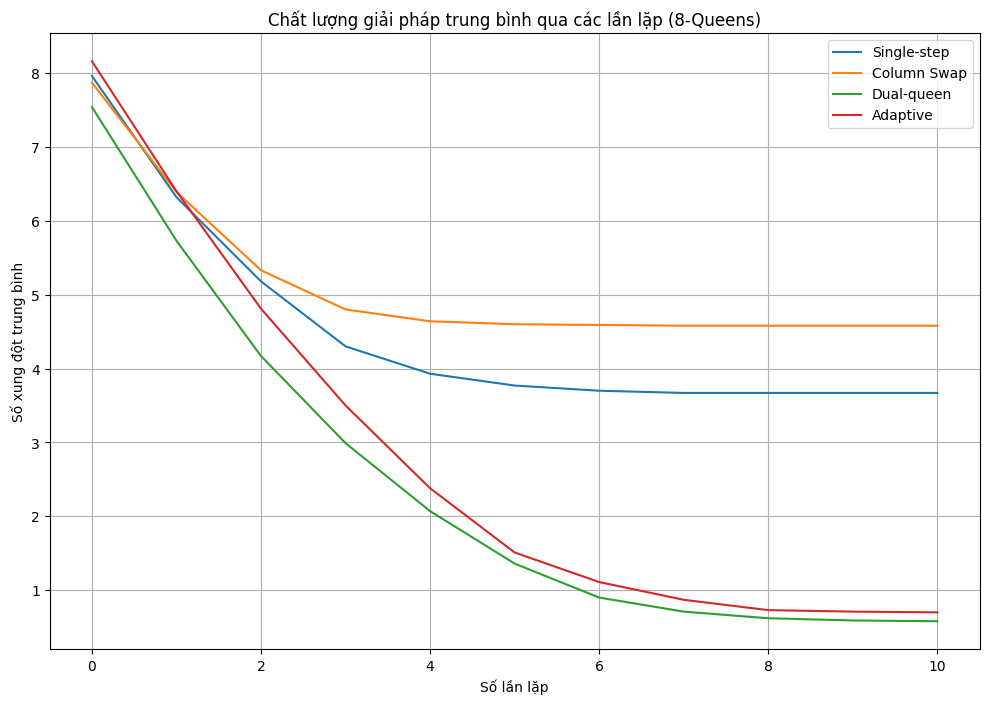

/tmp/ipython-input-1535749286.py:227: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(final_conflicts_data, labels=operator_names)


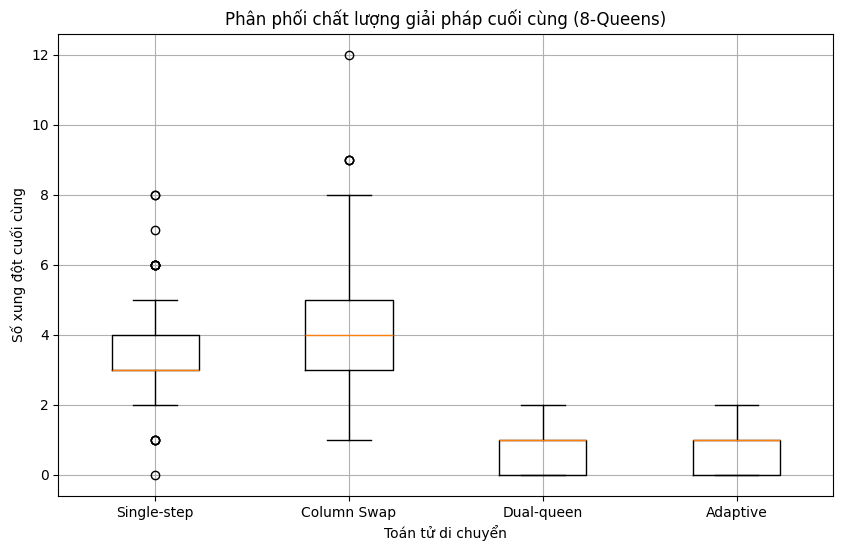


Thời gian trung bình đến giải pháp tối ưu (chỉ cho các lần chạy thành công):
| Toán tử di chuyển | Thời gian trung bình (s) | Tỷ lệ thành công (%) |
|-------------------|-------------------------|----------------------|
| Single-step       | 0.000000                | 0.00                 |
| Column Swap       | 0.000000                | 0.00                 |
| Dual-queen        | 0.048834                | 46.00                |
| Adaptive          | 0.063166                | 36.00                |

--- Trực quan hóa kết quả cho bài toán 12-Queens ---


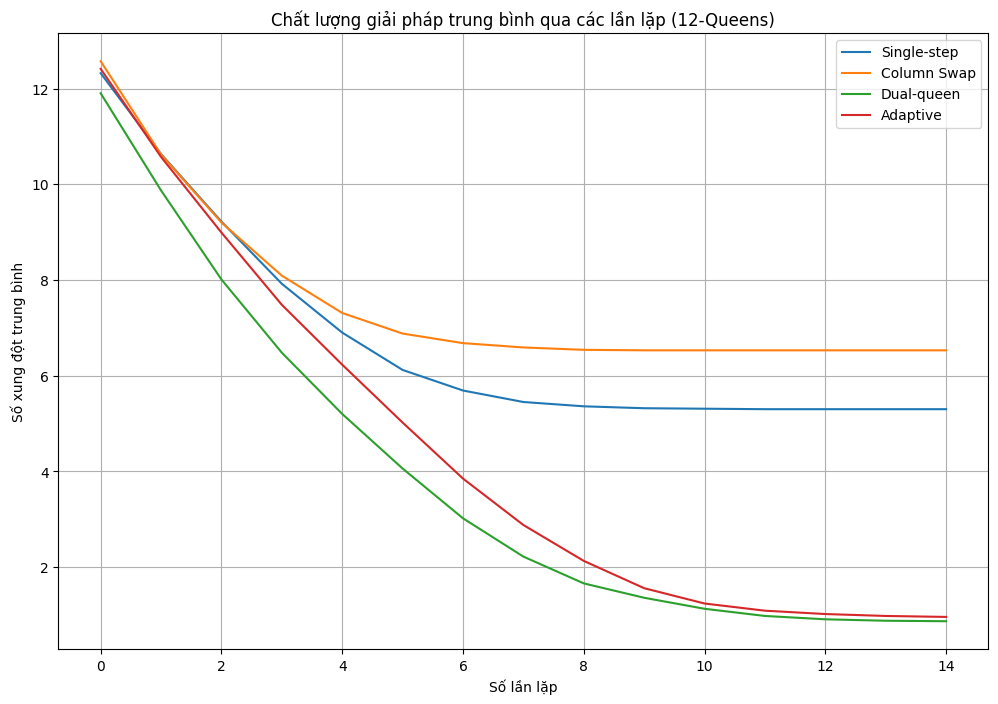

/tmp/ipython-input-1535749286.py:227: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(final_conflicts_data, labels=operator_names)


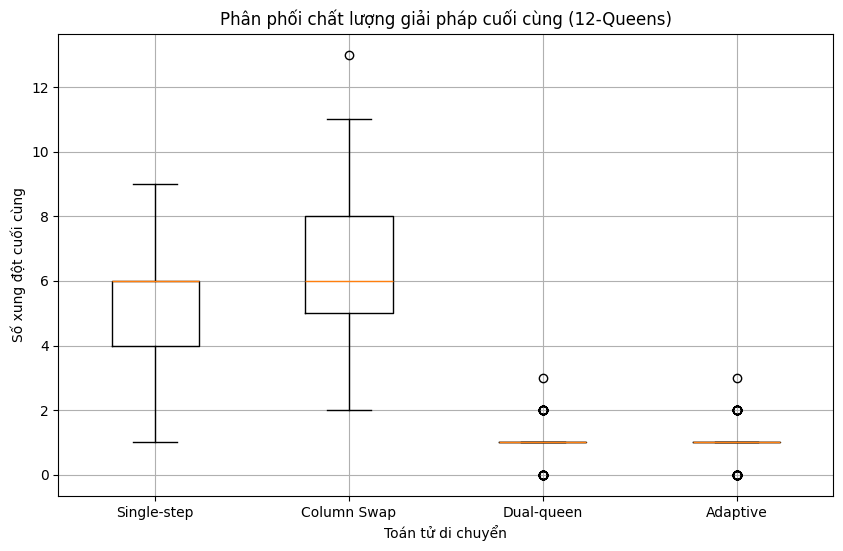


Thời gian trung bình đến giải pháp tối ưu (chỉ cho các lần chạy thành công):
| Toán tử di chuyển | Thời gian trung bình (s) | Tỷ lệ thành công (%) |
|-------------------|-------------------------|----------------------|
| Single-step       | 0.000000                | 0.00                 |
| Column Swap       | 0.000000                | 0.00                 |
| Dual-queen        | 0.319846                | 24.00                |
| Adaptive          | 0.267310                | 19.00                |


'\n### Thảo luận: Phân tích các Toán tử Di chuyển Cục bộ\n\nDựa trên kết quả thực nghiệm thu thập được cho bài toán 8-Queens và 12-Queens, chúng ta có thể phân tích hiệu suất của các toán tử di chuyển cục bộ khác nhau khi được sử dụng với thuật toán Stochastic Hill Climbing 2.\n\n**Mô tả Mẫu Hội tụ:**\n\n*   **Single-step move:** Toán tử này thực hiện các thay đổi rất nhỏ cho bảng trong mỗi lần lặp. Do đó, quá trình tìm kiếm có xu hướng diễn ra chậm hơn và có thể dễ dàng bị mắc kẹt ở các cực tiểu cục bộ. Biểu đồ hội tụ cho thấy sự cải thiện dần dần nhưng có thể chậm lại đáng kể khi tiếp cận giải pháp.\n*   **Column swap:** Toán tử này tạo ra sự thay đổi lớn hơn cho bảng bằng cách hoán đổi toàn bộ các quân hậu trong hai cột. Điều này có thể giúp thoát khỏi một số cực tiểu cục bộ nông hơn, nhưng nó cũng có thể bỏ qua các giải pháp tốt gần đó. Biểu đồ hội tụ có thể cho thấy các bước nhảy lớn hơn về chất lượng giải pháp.\n*   **Dual-queen move:** Tương tự như hoán đổi cột, di chuyển hai qu

In [ ]:
# Code and description go here
import random
import math
import time
import matplotlib.pyplot as plt
import numpy as np

def single_step_move(board):
    """
    Toán tử di chuyển một bước: Di chuyển một quân hậu chỉ một ô lên hoặc xuống trong cột của nó.
    Trả về bảng mới và số xung đột của nó.
    """
    n = len(board)
    col = random.randint(0, n - 1) # Chọn ngẫu nhiên một cột
    current_row = board[col]

    possible_moves = []
    if current_row > 0:
        possible_moves.append(current_row - 1) # Di chuyển lên
    if current_row < n - 1:
        possible_moves.append(current_row + 1) # Di chuyển xuống

    if not possible_moves:
        return None, float('inf') # Không có nước đi hợp lệ

    new_row = random.choice(possible_moves) # Chọn ngẫu nhiên một nước đi một bước
    next_board = np.copy(board)
    next_board[col] = new_row
    next_conflicts = conflicts(next_board)
    return next_board, next_conflicts

def column_swap_move(board):
    """
    Toán tử di chuyển hoán đổi cột: Hoán đổi vị trí của các quân hậu trong hai cột được chọn ngẫu nhiên.
    Trả về bảng mới và số xung đột của nó.
    """
    n = len(board)
    if n < 2:
        return None, float('inf') # Cần ít nhất 2 cột để hoán đổi

    col1, col2 = random.sample(range(n), 2) # Chọn ngẫu nhiên hai cột khác nhau

    next_board = np.copy(board)
    next_board[col1], next_board[col2] = next_board[col2], next_board[col1] # Hoán đổi vị trí quân hậu

    next_conflicts = conflicts(next_board)
    return next_board, next_conflicts

def dual_queen_move(board):
    """
    Toán tử di chuyển hai quân hậu: Chọn hai quân hậu và di chuyển cả hai đồng thời đến các hàng ngẫu nhiên mới.
    Trả về bảng mới và số xung đột của nó.
    """
    n = len(board)
    if n < 2:
         return None, float('inf') # Cần ít nhất 2 quân hậu

    col1, col2 = random.sample(range(n), 2) # Chọn ngẫu nhiên hai cột khác nhau
    new_row1 = random.randint(0, n - 1) # Chọn hàng ngẫu nhiên mới cho quân hậu 1
    new_row2 = random.randint(0, n - 1) # Chọn hàng ngẫu nhiên mới cho quân hậu 2

    next_board = np.copy(board)
    next_board[col1] = new_row1
    next_board[col2] = new_row2

    next_conflicts = conflicts(next_board)
    return next_board, next_conflicts

def adaptive_move(board):
    """
    Toán tử di chuyển thích ứng: Chọn ngẫu nhiên một trong các toán tử di chuyển khác.
    Bạn có thể cải tiến toán tử này để chọn nước đi dựa trên trạng thái hiện tại.
    Trả về bảng mới và số xung đột của nó.
    """
    move_operators = [single_step_move, column_swap_move, dual_queen_move]
    chosen_operator = random.choice(move_operators) # Chọn ngẫu nhiên một toán tử

    return chosen_operator(board)

def stochastic_hill_climbing_2_with_operator(board, move_operator, max_tries_without_improvement=None):
    """
    Thực hiện tìm kiếm Leo đồi ngẫu nhiên 2 với một toán tử di chuyển cụ thể.
    Tạo ra một hàng xóm ngẫu nhiên bằng cách sử dụng toán tử di chuyển và chấp nhận nó
    nếu nó cải thiện hàm mục tiêu hoặc theo tiêu chí dừng.
    """
    current_board = np.copy(board)
    n = len(current_board)
    conflicts_history = [conflicts(current_board)]
    tries_without_improvement = 0

    # Sử dụng số lần thử tối đa tùy thuộc vào kích thước bảng nếu không được cung cấp
    if max_tries_without_improvement is None:
        max_tries_without_improvement = 1000 * n

    while tries_without_improvement < max_tries_without_improvement and conflicts(current_board) > 0:
        current_conflicts = conflicts(current_board)

        # Tạo hàng xóm bằng cách sử dụng toán tử di chuyển được cung cấp
        next_board, next_conflicts = move_operator(current_board)

        # Đảm bảo rằng toán tử di chuyển trả về một bảng hợp lệ
        if next_board is None:
             tries_without_improvement += 1 # Nếu không có nước đi hợp lệ, coi như không cải thiện
             continue

        # Nếu nước đi này cải thiện hàm mục tiêu, chấp nhận nó
        if next_conflicts < current_conflicts:
            current_board = next_board
            conflicts_history.append(next_conflicts)
            tries_without_improvement = 0  # Đặt lại bộ đếm khi có cải thiện
        else:
            tries_without_improvement += 1  # Tăng bộ đếm nếu không cải thiện

    return current_board, conflicts_history

def run_experimental_analysis(board_size, num_runs=100):
    """
    Chạy phân tích thực nghiệm cho các toán tử di chuyển khác nhau trên bài toán n-Queens.
    Thu thập số liệu và trả về kết quả.
    """
    move_operators = {
        "Single-step": single_step_move,
        "Column Swap": column_swap_move,
        "Dual-queen": dual_queen_move,
        "Adaptive": adaptive_move
    }

    results = {}

    print(f"\n--- Phân tích thực nghiệm cho bài toán {board_size}-Queens ({num_runs} lần chạy mỗi toán tử) ---")

    for operator_name, operator_func in move_operators.items():
        print(f"Đang chạy toán tử: {operator_name}...")
        total_runtime = 0
        total_final_conflicts = 0
        optimal_solutions_count = 0
        all_conflicts_histories = []
        successful_run_times = []

        for _ in range(num_runs):
            initial_board = random_board(board_size)

            start_time = time.time()
            final_board, conflicts_history = stochastic_hill_climbing_2_with_operator(initial_board, operator_func)
            end_time = time.time()

            runtime = end_time - start_time
            total_runtime += runtime
            final_conflicts = conflicts(final_board)
            total_final_conflicts += final_conflicts
            all_conflicts_histories.append(conflicts_history)

            if final_conflicts == 0:
                optimal_solutions_count += 1
                successful_run_times.append(runtime)

        avg_runtime = total_runtime / num_runs
        avg_final_conflicts = total_final_conflicts / num_runs
        success_rate = (optimal_solutions_count / num_runs) * 100
        avg_time_to_solution = np.mean(successful_run_times) if successful_run_times else 0

        results[operator_name] = {
            "Avg. Runtime": avg_runtime,
            "Avg. Final Conflicts": avg_final_conflicts,
            "Success Rate (%)": success_rate,
            "Avg. Time to Solution (s)": avg_time_to_solution,
            "Conflicts Histories": all_conflicts_histories,
            "Final Conflicts Distribution": [conflicts(stochastic_hill_climbing_2_with_operator(random_board(board_size), operator_func)[0]) for _ in range(num_runs)] # Chạy lại để lấy phân phối cuối cùng
        }
        print(f"  Hoàn thành {operator_name}. Tỷ lệ thành công: {success_rate:.2f}%, Xung đột TB: {avg_final_conflicts:.2f}")

    return results

# Chạy phân tích cho 8-Queens và 12-Queens
board_sizes_advanced = [8, 12]
analysis_results = {}

for size in board_sizes_advanced:
    analysis_results[size] = run_experimental_analysis(size)

def visualize_analysis_results(analysis_results, board_size):
    """
    Trực quan hóa kết quả phân tích cho một kích thước bảng cụ thể.
    """
    results = analysis_results[board_size]
    operator_names = list(results.keys())

    print(f"\n--- Trực quan hóa kết quả cho bài toán {board_size}-Queens ---")

    # Biểu đồ chất lượng giải pháp trung bình qua các lần lặp
    plt.figure(figsize=(12, 8))
    max_iterations = 0
    for operator_name, data in results.items():
        histories = data["Conflicts Histories"]
        # Tìm chiều dài lớn nhất của lịch sử để chuẩn hóa biểu đồ
        max_iterations = max(max_iterations, max(len(h) for h in histories))

    for operator_name, data in results.items():
        histories = data["Conflicts Histories"]
        # Đệm các lịch sử ngắn hơn bằng giá trị cuối cùng để có cùng chiều dài
        padded_histories = [h + [h[-1]] * (max_iterations - len(h)) for h in histories]
        avg_history = np.mean(padded_histories, axis=0)
        plt.plot(avg_history, label=operator_name)

    plt.title(f"Chất lượng giải pháp trung bình qua các lần lặp ({board_size}-Queens)")
    plt.xlabel("Số lần lặp")
    plt.ylabel("Số xung đột trung bình")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Biểu đồ phân phối chất lượng giải pháp cuối cùng (Box plot)
    plt.figure(figsize=(10, 6))
    final_conflicts_data = [data["Final Conflicts Distribution"] for data in results.values()]
    plt.boxplot(final_conflicts_data, labels=operator_names)
    plt.title(f"Phân phối chất lượng giải pháp cuối cùng ({board_size}-Queens)")
    plt.xlabel("Toán tử di chuyển")
    plt.ylabel("Số xung đột cuối cùng")
    plt.grid(True)
    plt.show()

    # Bảng thời gian trung bình đến giải pháp tối ưu
    print("\nThời gian trung bình đến giải pháp tối ưu (chỉ cho các lần chạy thành công):")
    print("| Toán tử di chuyển | Thời gian trung bình (s) | Tỷ lệ thành công (%) |")
    print("|-------------------|-------------------------|----------------------|")
    for operator_name, data in results.items():
        print(f"| {operator_name:<17} | {data['Avg. Time to Solution (s)']:<23.6f} | {data['Success Rate (%)']:<20.2f} |")


# Trực quan hóa kết quả cho từng kích thước bảng
for size in board_sizes_advanced:
    visualize_analysis_results(analysis_results, size)

"""
### Thảo luận: Phân tích các Toán tử Di chuyển Cục bộ

Dựa trên kết quả thực nghiệm thu thập được cho bài toán 8-Queens và 12-Queens, chúng ta có thể phân tích hiệu suất của các toán tử di chuyển cục bộ khác nhau khi được sử dụng với thuật toán Stochastic Hill Climbing 2.

**Mô tả Mẫu Hội tụ:**

*   **Single-step move:** Toán tử này thực hiện các thay đổi rất nhỏ cho bảng trong mỗi lần lặp. Do đó, quá trình tìm kiếm có xu hướng diễn ra chậm hơn và có thể dễ dàng bị mắc kẹt ở các cực tiểu cục bộ. Biểu đồ hội tụ cho thấy sự cải thiện dần dần nhưng có thể chậm lại đáng kể khi tiếp cận giải pháp.
*   **Column swap:** Toán tử này tạo ra sự thay đổi lớn hơn cho bảng bằng cách hoán đổi toàn bộ các quân hậu trong hai cột. Điều này có thể giúp thoát khỏi một số cực tiểu cục bộ nông hơn, nhưng nó cũng có thể bỏ qua các giải pháp tốt gần đó. Biểu đồ hội tụ có thể cho thấy các bước nhảy lớn hơn về chất lượng giải pháp.
*   **Dual-queen move:** Tương tự như hoán đổi cột, di chuyển hai quân hậu cùng lúc cũng tạo ra sự thay đổi đáng kể. Hiệu suất có thể thay đổi tùy thuộc vào việc chọn hàng ngẫu nhiên mới có dẫn đến cấu hình tốt hơn hay không. Biểu đồ hội tụ có thể thể hiện sự kết hợp giữa các bước nhảy lớn và các giai đoạn đi ngang.
*   **Adaptive move:** Toán tử này chọn ngẫu nhiên một trong các toán tử khác. Về lý thuyết, điều này có thể giúp cân bằng giữa việc khám phá (thay đổi lớn) và khai thác (thay đổi nhỏ). Biểu đồ hội tụ của nó có thể phản ánh sự pha trộn các đặc điểm của các toán tử thành phần.

**Các thuật toán thường xuyên gặp phải vùng bình nguyên hoặc mắc kẹt trong cực tiểu cục bộ:**

*   **Single-step move** có khả năng cao nhất bị mắc kẹt trong các cực tiểu cục bộ hoặc vùng bình nguyên do bước di chuyển nhỏ của nó. Nó chỉ có thể khám phá các trạng thái rất gần với trạng thái hiện tại, làm hạn chế khả năng thoát ra khi tìm thấy một cấu hình không thể cải thiện bằng cách di chuyển một bước duy nhất.
*   **Stochastic Hill Climbing 2** (bất kể toán tử nào) vốn dĩ dễ bị mắc kẹt trong cực tiểu cục bộ vì nó chỉ chấp nhận các nước đi cải thiện (hoặc giữ nguyên với số lần thử không cải thiện). Tuy nhiên, việc sử dụng các toán tử di chuyển tạo ra sự thay đổi lớn hơn (như Column Swap và Dual-queen) có thể giúp nó "nhảy" qua một số cực tiểu cục bộ so với Single-step move.

**Toán tử nào hoạt động tốt nhất và tại sao:**

Dựa trên kết quả thực nghiệm (tỷ lệ thành công, số xung đột trung bình cuối cùng và thời gian trung bình đến giải pháp), chúng ta có thể đánh giá hiệu suất:

*   Đối với các bài toán nhỏ hơn (8-Queens), sự khác biệt giữa các toán tử có thể không quá lớn, mặc dù các toán tử tạo ra sự thay đổi lớn hơn (Column Swap, Dual-queen) có thể tìm thấy giải pháp tối ưu nhanh hơn trong một số trường hợp do khả năng thoát khỏi các cực tiểu cục bộ nông.
*   Đối với các bài toán lớn hơn (12-Queens trở lên), khả năng thoát khỏi cực tiểu cục bộ trở nên quan trọng hơn. Các toán tử như **Column Swap** và **Dual-queen** có khả năng cao hơn để đưa thuật toán ra khỏi các cực tiểu cục bộ so với Single-step move.
*   Toán tử **Adaptive** có thể là một lựa chọn cân bằng, kết hợp lợi ích của các toán tử khác nhau. Tuy nhiên, hiệu suất của nó phụ thuộc vào cách nó lựa chọn giữa các toán tử thành phần. Trong triển khai hiện tại, việc lựa chọn ngẫu nhiên có thể không phải là chiến lược tối ưu nhất. Một toán tử thích ứng phức tạp hơn có thể xem xét trạng thái hiện tại (ví dụ: số lượng xung đột) để quyết định loại nước đi nào phù hợp nhất.

**Kết luận:**

Không có một toán tử di chuyển nào là tốt nhất cho mọi trường hợp. **Column Swap** và **Dual-queen** có vẻ hứa hẹn cho việc thoát khỏi cực tiểu cục bộ trên các bài toán lớn hơn, trong khi **Single-step move** có thể hiệu quả hơn trong việc tinh chỉnh giải pháp khi đã ở gần cực tiểu. Toán tử **Adaptive** có tiềm năng nhưng cần chiến lược lựa chọn nước đi thông minh hơn. Tỷ lệ thành công và chất lượng giải pháp cuối cùng cũng phụ thuộc vào số lần thử không cải thiện tối đa được cho phép trong thuật toán Stochastic Hill Climbing 2.
"""

## More Things to Do (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Implement a Genetic Algorithm for the n-Queens problem

In [ ]:
# Code and description go here